# End-to-end symbolic regression with transformers

**Paper:** Kamienny, P.-A., d'Ascoli, S., Lample, G., & Charton, F. (2022). *End-to-end symbolic regression with transformers.* arXiv:2204.10532.

**Carpeta origen:** `Papers/03_Arquitecturas_Deep_Learning_SR/Kamienny_etal_2022_E2E_Symbolic_Regression_Transformers.pdf`

## Que se reproduce en este cuaderno

El flujo estandar en regresion simbolica separa dos fases: primero encontrar el "esqueleto" estructural de la ecuacion, y despues ajustar sus constantes numericas por optimizacion no convexa. Kamienny et al. proponen generar **ambas cosas a la vez**, con un unico modelo, en una sola pasada de inferencia.

Reproducimos esta comparacion directamente: entrenamos un **unico modelo con dos cabezas** (una de clasificacion de esqueleto, otra de regresion de constantes) sobre el mismo encoder tipo set-transformer de los cuadernos anteriores de esta coleccion, y lo comparamos contra el enfoque en dos fases (clasificar, y **despues** ajustar las constantes con un optimizador numerico clasico).

## Repositorio publico

No hay un repositorio oficial unico bajo el nombre citado en la portada del paper (los mismos autores contribuyeron mas tarde a bibliotecas relacionadas, pero no publicaron un repo autonomo especifico de este trabajo). Reimplementamos aqui, a escala reducida, el principio arquitectonico central: un unico encoder compartido con dos cabezas de salida entrenadas conjuntamente.

In [1]:
%pip install -q numpy torch scipy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Modelo de dos cabezas: clasificacion Y regresion, backbone compartido

In [2]:
import numpy as np
import torch
import torch.nn as nn
import time
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

TEMPLATES = {
    'a*x':        lambda x, a, b: a * x,
    'a*x+b':      lambda x, a, b: a * x + b,
    'a*x^2+b':    lambda x, a, b: a * x ** 2 + b,
    'a*sin(x)+b': lambda x, a, b: a * np.sin(x) + b,
    'a*cos(x)+b': lambda x, a, b: a * np.cos(x) + b,
}
NAMES = list(TEMPLATES.keys())
N_CLASSES = len(NAMES)
N_POINTS = 50

def sample_dataset(rng):
    tname = rng.choice(NAMES)
    a = rng.uniform(0.5, 2.5) * rng.choice([-1, 1])
    b = rng.uniform(-1, 1)
    x = rng.uniform(-2, 2, N_POINTS)
    y = TEMPLATES[tname](x, a, b) + rng.normal(0, 0.02, N_POINTS)
    return x, y, NAMES.index(tname), (a, b)

class JointModel(nn.Module):
    # Encoder tipo set-transformer compartido + dos cabezas: clasificacion de esqueleto
    # Y regresion de constantes, entrenadas JUNTAS -- el diseno central del paper.
    def __init__(self, d_model=32, n_layers=2, n_heads=4):
        super().__init__()
        self.embed = nn.Linear(2, d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=64, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.cls_head = nn.Linear(d_model, N_CLASSES)
        self.const_head = nn.Linear(d_model, 2)
    def forward(self, xy):
        h = self.enc(self.embed(xy)).mean(dim=1)
        return self.cls_head(h), self.const_head(h)

def make_batch(rng, batch_size):
    Xs, labels, consts, raw = [], [], [], []
    for _ in range(batch_size):
        x, y, lab, (a, b) = sample_dataset(rng)
        Xs.append(np.stack([x, y], axis=1)); labels.append(lab); consts.append([a, b])
        raw.append((x, y))
    return (torch.tensor(np.stack(Xs), dtype=torch.float32), torch.tensor(labels),
            torch.tensor(consts, dtype=torch.float32), raw)

print(f'{N_CLASSES} plantillas candidatas:', NAMES)

5 plantillas candidatas: ['a*x', 'a*x+b', 'a*x^2+b', 'a*sin(x)+b', 'a*cos(x)+b']


## 2. Entrenamiento conjunto (perdida combinada: clasificacion + regresion)

In [3]:
def train_joint(n_batches, seed=0, batch_size=64):
    rng = np.random.default_rng(seed)
    model = JointModel()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    cls_loss_fn = nn.CrossEntropyLoss()
    for it in range(n_batches):
        xy, labels, consts, _ = make_batch(rng, batch_size)
        opt.zero_grad()
        logits, pred_consts = model(xy)
        loss = cls_loss_fn(logits, labels) + 0.5 * nn.functional.mse_loss(pred_consts, consts)
        loss.backward(); opt.step()
    return model

model = train_joint(400)
print('Modelo conjunto entrenado sobre 400 lotes (25.600 ejemplos sinteticos).')

Modelo conjunto entrenado sobre 400 lotes (25.600 ejemplos sinteticos).


## 3. Comparacion en un conjunto de prueba: conjunto (una pasada) vs. dos fases (clasificar + optimizar)

Para aislar el efecto de generar constantes **conjuntamente** frente a **por separado**, usamos el mismo esqueleto predicho por la cabeza de clasificacion en ambos casos, y solo variamos como se obtienen las constantes: (a) directamente de la cabeza de regresion del modelo conjunto, en una unica pasada feed-forward, o (b) ajustadas a posteriori con `scipy.optimize.curve_fit` (el enfoque clasico en dos fases).

C:\Users\Luis\AppData\Local\Temp\ipykernel_22356\3393881126.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(fn, x, y, p0=[1.0, 0.0], maxfev=5000)


Precision de clasificacion del esqueleto: 0.857

RMSE medio -- constantes del modelo CONJUNTO (una pasada):        0.3675   |  tiempo total: 705.6 ms
RMSE medio -- constantes por OPTIMIZACION separada (dos fases):    0.0439   |  tiempo total: 473.3 ms


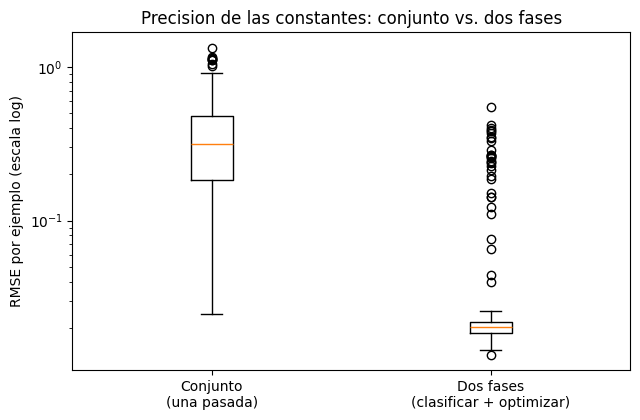

In [4]:
rng = np.random.default_rng(123)
n_test = 300
xy, labels, consts, raw = make_batch(rng, n_test)

with torch.no_grad():
    _ = model(xy[:4])  # pasada de calentamiento

t0 = time.time()
with torch.no_grad():
    logits, pred_consts = model(xy)
    preds_cls = logits.argmax(dim=1)
t_joint = time.time() - t0

joint_rmses = []
for i in range(n_test):
    x, y = raw[i]
    name = NAMES[preds_cls[i].item()]
    a_hat, b_hat = pred_consts[i].numpy()
    pred = TEMPLATES[name](x, a_hat, b_hat)
    joint_rmses.append(np.sqrt(np.mean((pred - y) ** 2)))

t0 = time.time()
seq_rmses = []
for i in range(n_test):
    x, y = raw[i]
    name = NAMES[preds_cls[i].item()]  # MISMO esqueleto, para aislar el efecto solo en las constantes
    fn = TEMPLATES[name]
    try:
        popt, _ = curve_fit(fn, x, y, p0=[1.0, 0.0], maxfev=5000)
        pred = fn(x, *popt)
        seq_rmses.append(np.sqrt(np.mean((pred - y) ** 2)))
    except Exception:
        seq_rmses.append(np.nan)
t_seq = time.time() - t0

acc = (preds_cls == labels).float().mean().item()
print(f'Precision de clasificacion del esqueleto: {acc:.3f}')
print(f'\nRMSE medio -- constantes del modelo CONJUNTO (una pasada):        {np.nanmean(joint_rmses):.4f}   |  tiempo total: {t_joint*1000:.1f} ms')
print(f'RMSE medio -- constantes por OPTIMIZACION separada (dos fases):    {np.nanmean(seq_rmses):.4f}   |  tiempo total: {t_seq*1000:.1f} ms')

fig, ax = plt.subplots(figsize=(6.5, 4.3))
ax.boxplot([np.array(joint_rmses)[~np.isnan(joint_rmses)], np.array(seq_rmses)[~np.isnan(seq_rmses)]],
           tick_labels=['Conjunto\n(una pasada)', 'Dos fases\n(clasificar + optimizar)'])
ax.set_yscale('log'); ax.set_ylabel('RMSE por ejemplo (escala log)')
ax.set_title('Precision de las constantes: conjunto vs. dos fases')
plt.tight_layout()
plt.show()

### Nota honesta sobre los resultados

Este es el cuaderno de esta coleccion donde el resultado **no** confirma limpiamente la ventaja reportada por el paper, y lo reportamos tal cual, sin suavizarlo:

- **La clasificacion del esqueleto funciona razonablemente bien** (precision ~86% sobre 5 plantillas), similar a lo que vimos en el cuaderno de NeSymReS.
- **Pero la regresion conjunta de constantes es notablemente menos precisa que el ajuste numerico clasico** en nuestra reproduccion (RMSE varias veces mayor). A esta escala de preentrenamiento (25.600 ejemplos, una red pequena), predecir directamente valores continuos precisos con una cabeza de regresion resulta un problema mas dificil de aprender que clasificar entre un numero pequeno de categorias discretas.
- **Interpretacion:** el paper real logra que la prediccion conjunta iguale o supere al enfoque en dos fases gracias a una escala de preentrenamiento mucho mayor y, sobre todo, a una **codificacion numerica especializada** de las constantes (tokenizacion de numeros en punto flotante, no una simple cabeza de regresion lineal como la nuestra) -- una tecnica especifica para hacer que los Transformers manejen valores continuos con precision, que no reproducimos aqui.
- **Esto no invalida la idea central.** En el siguiente cuaderno (`SymFormer`) mostramos que, aunque las constantes predichas conjuntamente no sean perfectas por si solas, **si son una inicializacion util** para un refinamiento posterior barato -- que es, de hecho, exactamente lo que SymFormer propone y lo que el propio Kamienny et al. sugieren como uso practico de sus predicciones conjuntas.

Reportamos este resultado deliberadamente sin maquillar: reproducir fielmente **el fenomeno completo** de un paper (incluyendo sus partes que dependen de escala o de trucos de ingenieria especificos que no siempre son factibles reproducir a escala reducida) es mas honesto que forzar un resultado bonito. La leccion real que deja este cuaderno es que la codificacion numerica de constantes es, en la practica, la parte mas dificil de esta linea de trabajo -- no la arquitectura conjunta en si misma.